# Scenario Comparison Analysis

In [18]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [19]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_base_"

# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "not_windy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "wind_variability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["not_windy"]
n3 = networks["wind_variability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


### Grid Congestion and Curtailment

##### Marginal Prices

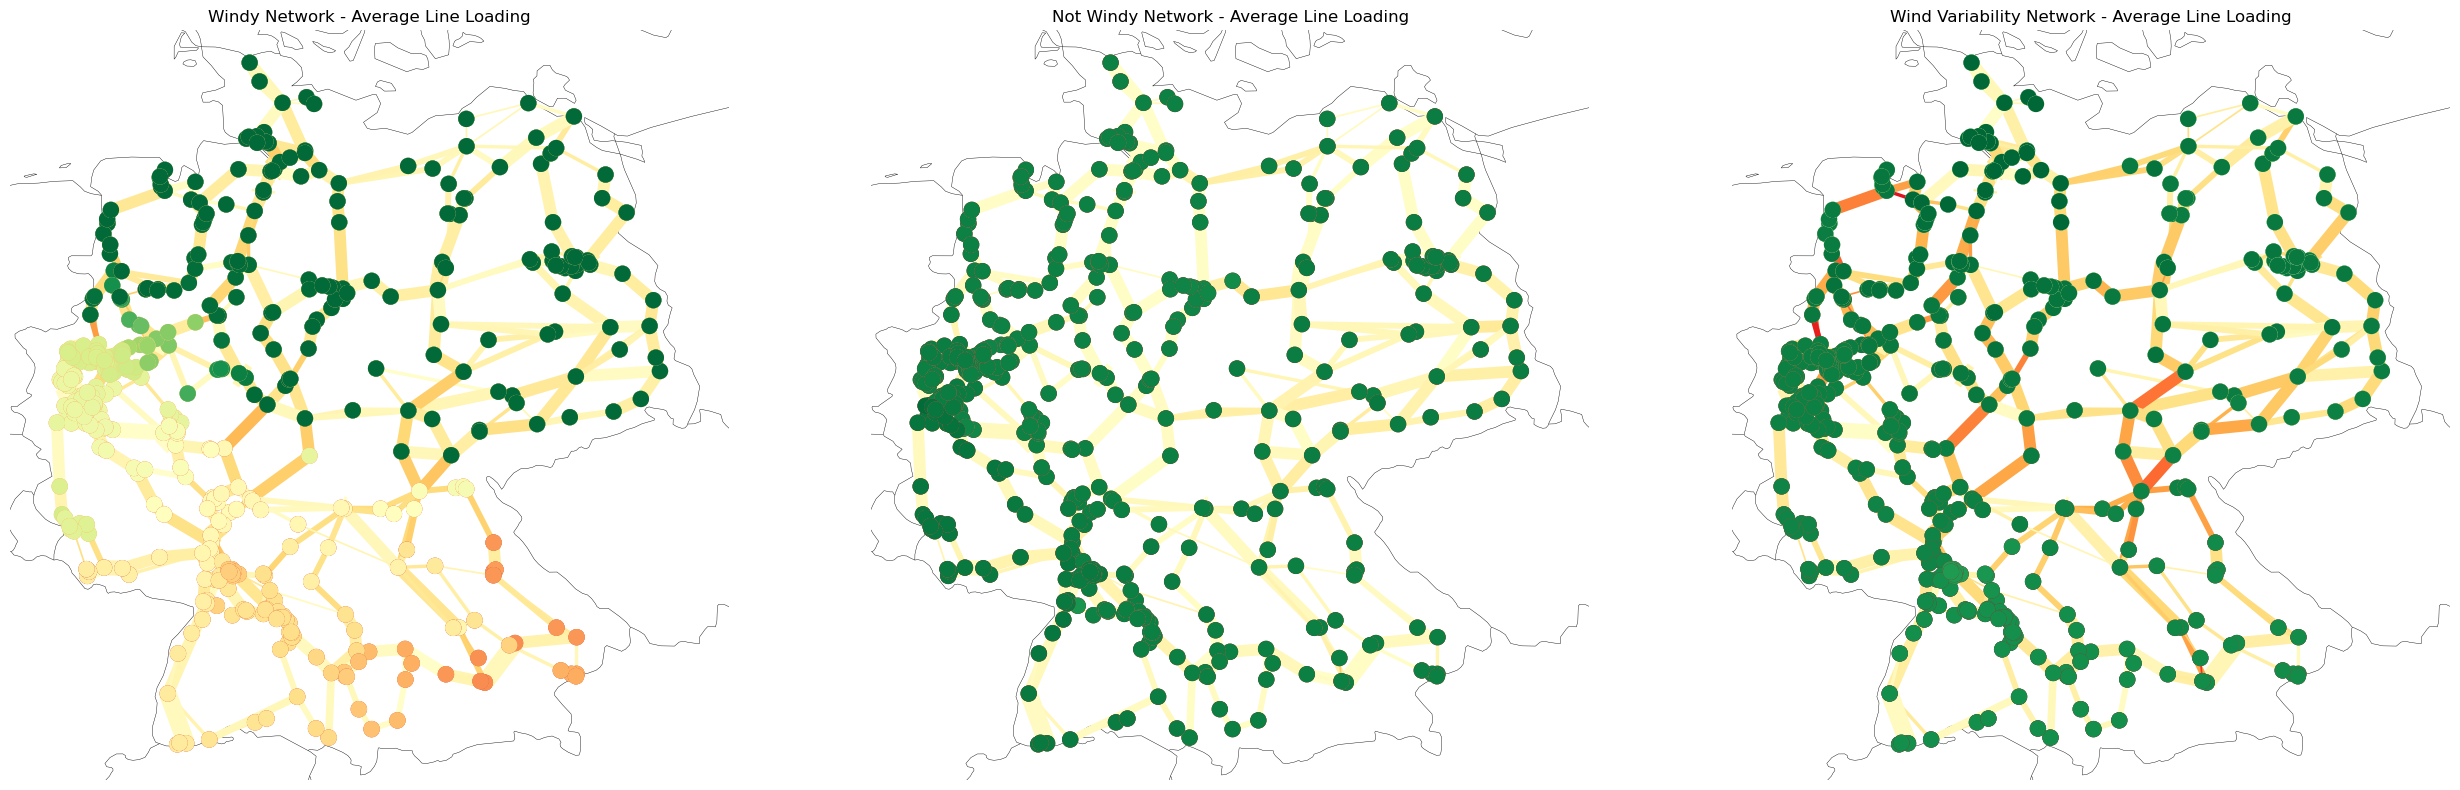

In [20]:
# --- Calculate average loading across all snapshots ---
avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]

    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01, # Size buses by marginal price
        bus_colors=peak_prices,       # Color buses by marginal price
        bus_cmap='RdYlGn_r',
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

### Load shedding

No generator carrier containing 'load' found. Plot will show zeros.
No generator carrier containing 'load' found. Plot will show zeros.
No generator carrier containing 'load' found. Plot will show zeros.


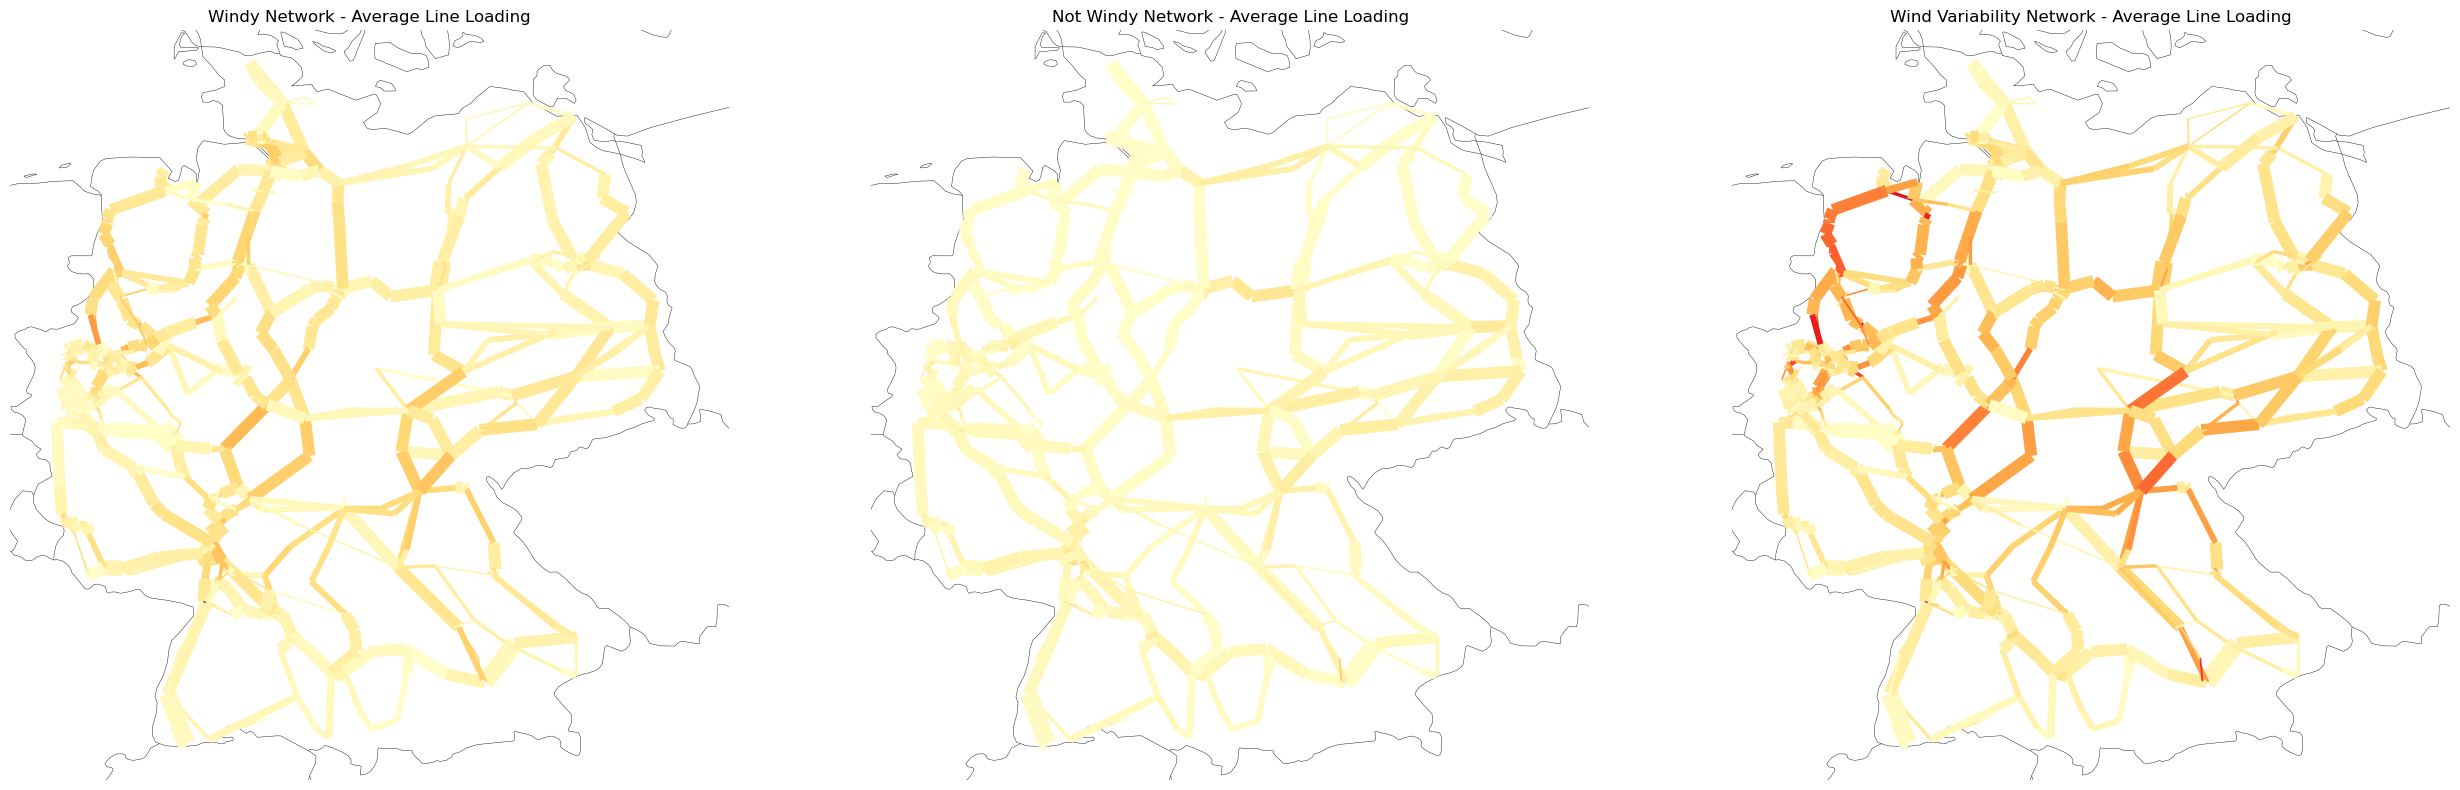

In [21]:
# --- Calculate average loading across all snapshots ---
avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        used_carriers = sorted(n.generators.loc[shed_gens, "carrier"].unique())
        print(f"Using load-related carriers: {used_carriers}")

        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )


    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]


    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        #bus_sizes=0.01, # Size buses by unmet load at worst snapshot
        bus_sizes=unmet_load_at_snapshot/5000,
        #bus_colors=unmet_load_at_snapshot,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

In [22]:
# --- Print congestion statistics ---
print("\n" + "=" * 70)
print("CONGESTION STATISTICS")
print("=" * 70)
print(f"\nWindy Network:")
print(f"  Average loading across all lines: {avg_loading_n1.mean():.2%}")
print(f"  Max average loading: {avg_loading_n1.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n1 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n1 > 0.7).sum()}")

print(f"\nNot Windy Network:")
print(f"  Average loading across all lines: {avg_loading_n2.mean():.2%}")
print(f"  Max average loading: {avg_loading_n2.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n2 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n2 > 0.7).sum()}")

print(f"\nWind Variability Network:")
print(f"  Average loading across all lines: {avg_loading_n3.mean():.2%}")
print(f"  Max average loading: {avg_loading_n3.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n3 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n3 > 0.7).sum()}")
print("=" * 70)


CONGESTION STATISTICS

Windy Network:
  Average loading across all lines: 29.47%
  Max average loading: 243.55%
  Lines with >60% avg loading: 58
  Lines with >70% avg loading: 23

Not Windy Network:
  Average loading across all lines: 15.45%
  Max average loading: 313.40%
  Lines with >60% avg loading: 6
  Lines with >70% avg loading: 4

Wind Variability Network:
  Average loading across all lines: 33.64%
  Max average loading: 164.80%
  Lines with >60% avg loading: 89
  Lines with >70% avg loading: 52


##### Offshore Wind Curtailment

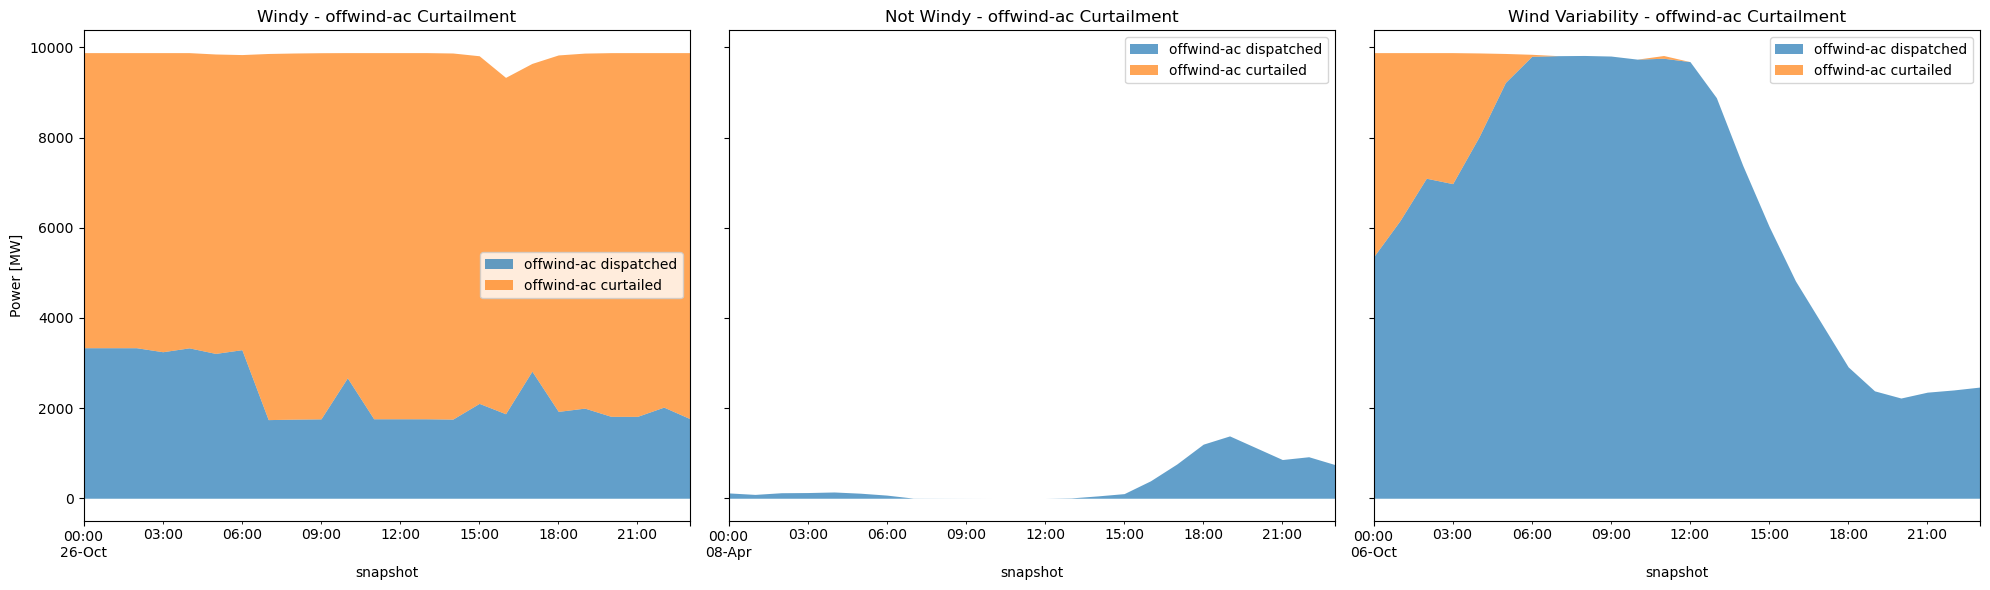

In [23]:
def plot_curtailment(n, carrier, ax):
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    p_dispatched = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed = p_available - p_dispatched
    
    # Correct for any minor negative values from floating point inaccuracies
    p_curtailed[p_curtailed < 0] = 0
    
    df = pd.DataFrame({
        f"{carrier} dispatched": p_dispatched[carrier],
        f"{carrier} curtailed": p_curtailed[carrier]
    })
    
    df.plot(kind="area", ax=ax, lw=0, alpha=0.7)
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    ax.set_ylabel("Power [MW]")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])


plt.tight_layout()
plt.show()

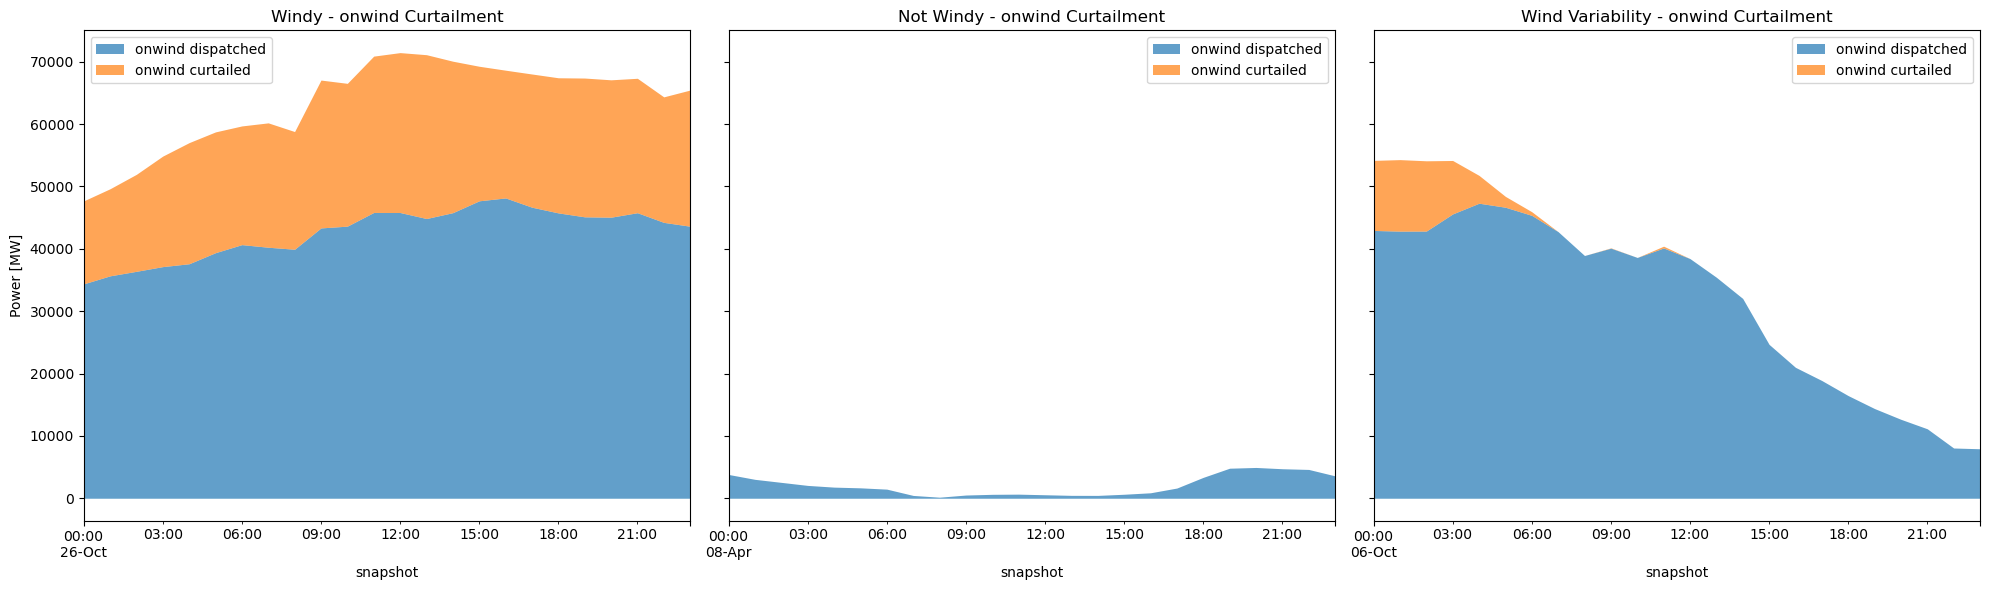

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

In [31]:
p_by_carrier = n1.generators_t.p.T.groupby(n1.generators.carrier).sum().T
print(p_by_carrier.sum())

carrier
CCGT             7.974896e-04
OCGT             1.017675e-03
biomass          4.220986e+01
coal             7.041488e+00
geothermal       6.455907e+02
lignite          1.419211e-04
offwind-ac       5.623280e+04
offwind-dc       0.000000e+00
offwind-float    0.000000e+00
oil              4.451316e-04
onwind           1.022822e+06
ror              4.002598e+04
solar            6.821667e+04
solar-hsat       0.000000e+00
waste            5.988160e-04
dtype: float64


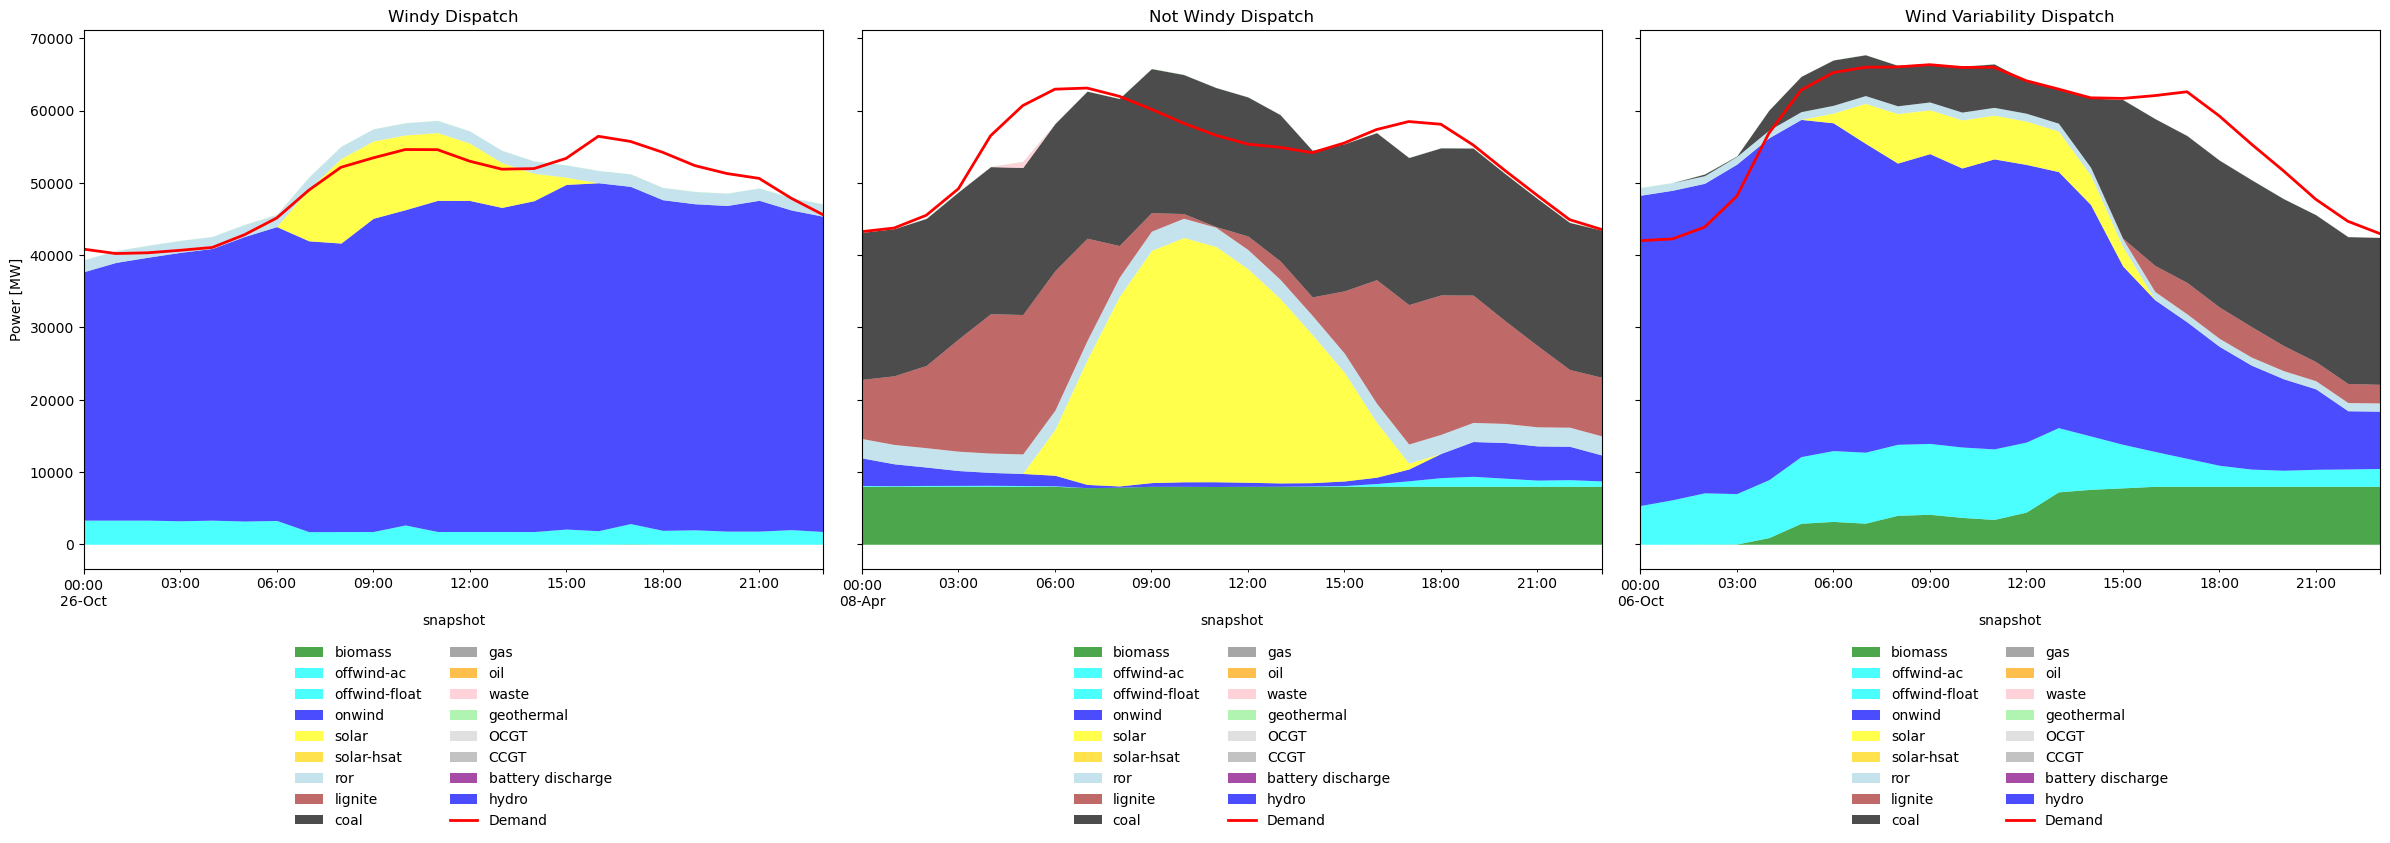

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "offwind-float": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "lightgreen",
    "OCGT": "lightgray", "CCGT": "darkgray", "battery discharge": "purple", 
    "hydro": "blue", "ror": "lightblue", "solar-hsat": "gold"
}

cols = [
    "biomass", "offwind-ac", "offwind-float", "onwind", "solar", "solar-hsat", "ror", "lignite", "coal", "gas", "oil", "waste", "geothermal", "OCGT", "CCGT", "battery discharge", "hydro"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

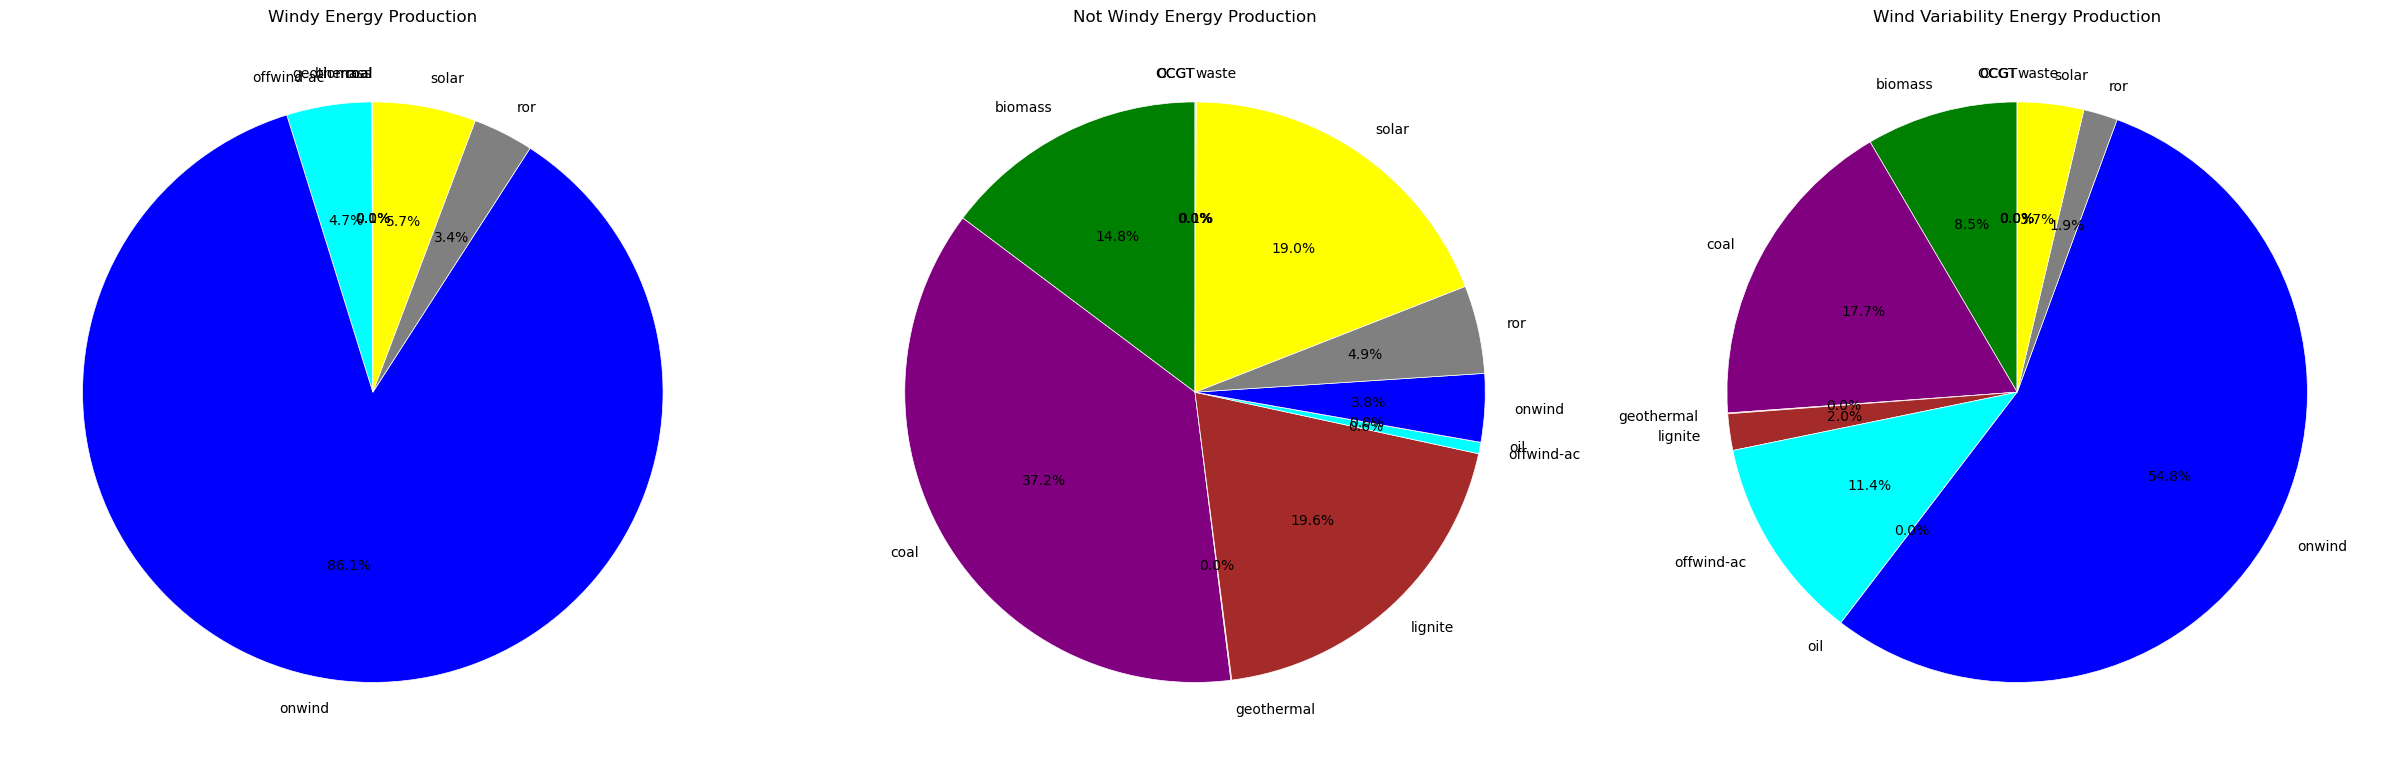

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# --- Define Colors and Order (same as dispatch plot) ---
colors = {
    "biomass": "green", "coal": "purple", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "purple", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray", "load": "red"
}

# --- Helper function for plotting pie chart ---
def plot_energy_pie(p_by_carrier, ax, title):
    energy_total = p_by_carrier.sum()
    # Filter out carriers with zero or negligible energy
    energy_total = energy_total[energy_total > 0.1]
    
    # Get colors for the carriers that are present
    pie_colors = [colors.get(carrier, "grey") for carrier in energy_total.index]

    energy_total.plot(
        kind="pie", 
        ax=ax, 
        autopct='%1.1f%%', 
        startangle=90, 
        title=title,
        colors=pie_colors,
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'} # Add white borders for clarity
    )
    ax.set_ylabel("")

# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.T.groupby(n1.generators.carrier).sum().T
p_by_carrier_n2 = n2.generators_t.p.T.groupby(n2.generators.carrier).sum().T
p_by_carrier_n3 = n3.generators_t.p.T.groupby(n3.generators.carrier).sum().T


# --- Plotting ---
plot_energy_pie(p_by_carrier_n1, axes[0], "Windy Energy Production")
plot_energy_pie(p_by_carrier_n2, axes[1], "Not Windy Energy Production")
plot_energy_pie(p_by_carrier_n3, axes[2], "Wind Variability Energy Production")


plt.tight_layout()
plt.show()